# DE4W Live Activity Recognition: Model Training

In this notebook, we build the offline training part of a small live activity recognition system.

The complete project pipeline is:

```text
WISDM phone accelerometer data
→ load raw sensor files
→ select target activities
→ create time windows
→ extract statistical features
→ train a Random Forest model
→ compare random split vs. subject-wise split
→ export model artifacts
→ use the model later in FastAPI, Streamlit and phyphox
```

The goal is not to build the best possible activity recognition model.  
The goal is to understand the complete engineering pipeline from raw wearable data to a deployable model.

## 1. Imports and project paths

We use `pathlib` so that paths are easier to read and more robust than plain strings.

This notebook is expected to be located in:

```text
de4w-live-activity-app/notebooks/
```

Therefore, the project root is one level above the current notebook folder.

In [2]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)

Project root: /Users/konak/HPI/Vorlesungen/Data Engineering for Wearables SS2026/Mini-Project/de4w-live-activity-app
Data directory: /Users/konak/HPI/Vorlesungen/Data Engineering for Wearables SS2026/Mini-Project/de4w-live-activity-app/data
Model directory: /Users/konak/HPI/Vorlesungen/Data Engineering for Wearables SS2026/Mini-Project/de4w-live-activity-app/models


## 2. Activity mapping

The WISDM raw files use single-letter activity codes.

For the first prototype, we focus on three activities:

- `walking`
- `sitting`
- `standing`

This keeps the task simple and makes the later live demo more robust.

In [4]:
ACTIVITY_MAP = {
    "A": "walking",
    "B": "jogging",
    "C": "stairs",
    "D": "sitting",
    "E": "standing",
    "F": "typing",
    "G": "brushing_teeth",
    "H": "eating_soup",
    "I": "eating_chips",
    "J": "eating_pasta",
    "K": "drinking",
    "L": "eating_sandwich",
    "M": "kicking",
    "O": "catch",
    "P": "dribbling",
    "Q": "writing",
    "R": "clapping",
    "S": "folding_clothes",
}

TARGET_ACTIVITIES = [
    "walking",
    "sitting",
    "standing",
]

## 3. Load WISDM phone accelerometer data

The WISDM phone accelerometer data is stored as one file per subject.

Example file name:

```text
data_1600_accel_phone.txt
```

Each line has the format:

```text
subject_id, activity_code, timestamp, x, y, z;
```

Example:

```text
1600,A,252207666810782,-0.36476135,8.793503,1.0550842;
```

The final `z` value contains a trailing semicolon, which we remove during loading.

In [8]:
def load_single_wisdm_file(file_path: Path) -> pd.DataFrame:
    """
    Load one WISDM phone accelerometer file.

    Parameters
    ----------
    file_path:
        Path to a file such as data_1600_accel_phone.txt.

    Returns
    -------
    pandas.DataFrame
        DataFrame with subject_id, activity_code, timestamp, x, y, z and activity.
    """
    df = pd.read_csv(
        file_path,
        header=None,
        names=["subject_id", "activity_code", "timestamp", "x", "y", "z"],
        sep=",",
    )

    # The raw WISDM files end each line with a semicolon after the z value.
    df["z"] = (
        df["z"]
        .astype(str)
        .str.replace(";", "", regex=False)
        .astype(float)
    )

    df["activity"] = df["activity_code"].map(ACTIVITY_MAP)

    return df

In [9]:
def load_wisdm_phone_accel(
    data_dir: Path,
    target_activities: list[str] | None = None,
) -> pd.DataFrame:
    """
    Load all WISDM phone accelerometer files from a directory.

    Parameters
    ----------
    data_dir:
        Directory containing data_*_accel_phone.txt files.

    target_activities:
        Optional list of activity names to keep.

    Returns
    -------
    pandas.DataFrame
        Combined DataFrame containing all selected subjects and activities.
    """
    files = sorted(data_dir.glob("data_*_accel_phone.txt"))

    if not files:
        raise FileNotFoundError(
            f"No WISDM phone accelerometer files found in {data_dir}. "
            "Please place the raw/phone/accel files in the data directory."
        )

    all_dfs = []

    for file_path in files:
        df = load_single_wisdm_file(file_path)

        if target_activities is not None:
            df = df[df["activity"].isin(target_activities)]

        all_dfs.append(df)

    return pd.concat(all_dfs, ignore_index=True)

In [10]:
df = load_wisdm_phone_accel(
    DATA_DIR,
    target_activities=TARGET_ACTIVITIES,
)

df.head()

,subject_id,activity_code,timestamp,x,y,z,activity
0,1600,A,252207666810782,-0.364761,8.793503,1.055084,walking
1,1600,A,252207717164786,-0.879730,9.768784,1.016998,walking
2,1600,A,252207767518790,2.001495,11.109070,2.619156,walking
3,1600,A,252207817872794,0.450623,12.651642,0.184555,walking
4,1600,A,252207868226798,-2.164352,13.928436,-4.422485,walking


In [11]:
print("Shape:", df.shape)
print("Number of subjects:", df["subject_id"].nunique())

df["activity"].value_counts()

Shape: (814013, 7)
Number of subjects: 51


activity
walking     279817
standing    269604
sitting     264592
Name: count, dtype: int64

## 4. Add acceleration magnitude

The accelerometer has three axes: `x`, `y`, and `z`.

However, a smartphone can be held in different orientations.  
A simple way to reduce dependence on the coordinate system is to compute the acceleration magnitude:

$$
m = \sqrt{x^2 + y^2 + z^2}
$$

This does not solve all orientation problems, but it is a useful baseline feature for activity recognition.

In [12]:
df["magnitude"] = np.sqrt(
    df["x"] ** 2 +
    df["y"] ** 2 +
    df["z"] ** 2
)

df.head()

,subject_id,activity_code,timestamp,x,y,z,activity,magnitude
0,1600,A,252207666810782,-0.364761,8.793503,1.055084,walking,8.864082
1,1600,A,252207717164786,-0.879730,9.768784,1.016998,walking,9.860900
2,1600,A,252207767518790,2.001495,11.109070,2.619156,walking,11.587812
3,1600,A,252207817872794,0.450623,12.651642,0.184555,walking,12.661010
4,1600,A,252207868226798,-2.164352,13.928436,-4.422485,walking,14.773088


## 5. Explore raw signals

Before building a model, we inspect the raw signal.

This helps us understand whether the activities show visible differences in the accelerometer data.

In [13]:
def plot_activity_signal(
    df: pd.DataFrame,
    activity: str,
    subject_id: int | None = None,
    n_samples: int = 400,
) -> None:
    """
    Plot x, y, z and magnitude for one activity.

    Parameters
    ----------
    df:
        DataFrame containing raw sensor data.

    activity:
        Activity name to plot.

    subject_id:
        Optional subject id. If None, the first available samples are used.

    n_samples:
        Number of samples to plot.
    """
    if subject_id is not None:
        sample = df[
            (df["activity"] == activity) &
            (df["subject_id"] == subject_id)
        ].copy()
    else:
        sample = df[df["activity"] == activity].copy()

    sample = sample.head(n_samples).reset_index(drop=True)

    plt.figure(figsize=(12, 4))
    plt.plot(sample["x"], label="x")
    plt.plot(sample["y"], label="y")
    plt.plot(sample["z"], label="z")
    plt.plot(sample["magnitude"], label="magnitude", linewidth=2)
    plt.title(f"Phone accelerometer signal: {activity}")
    plt.xlabel("Sample")
    plt.ylabel("Acceleration [m/s²]")
    plt.legend()
    plt.show()

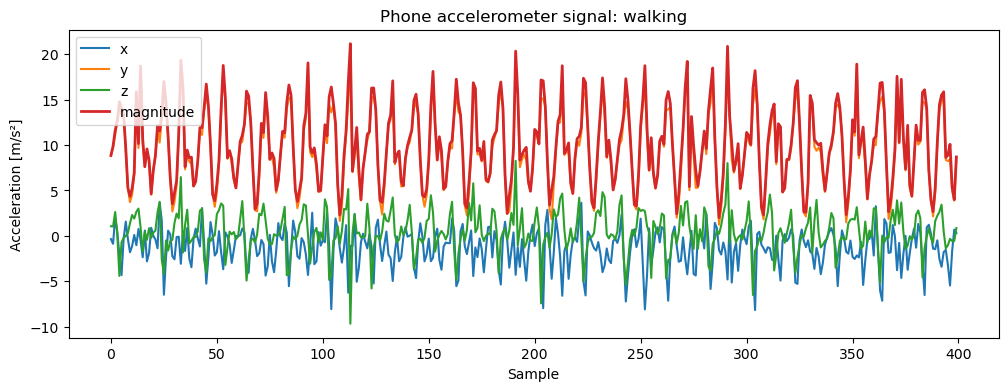

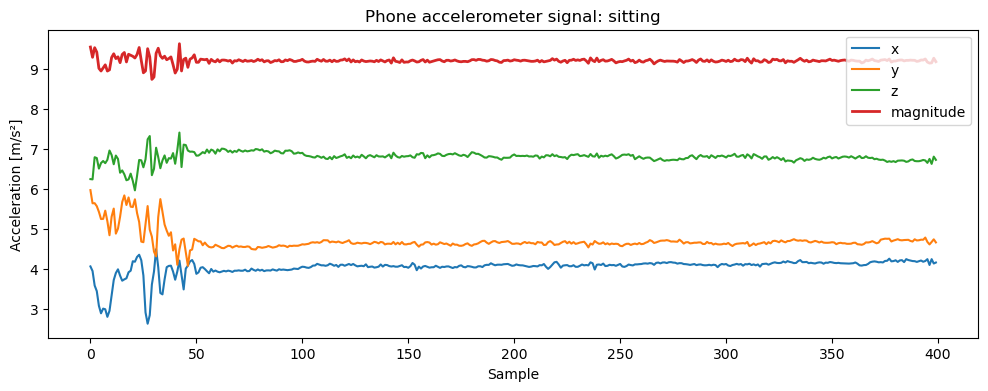

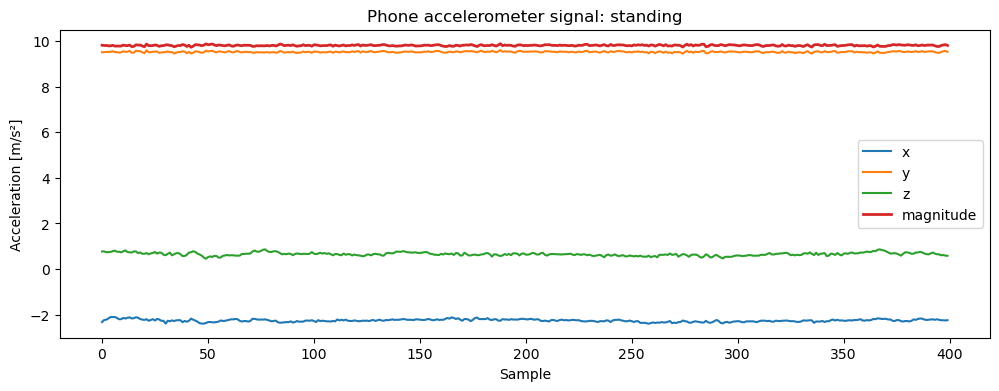

In [14]:
for activity in TARGET_ACTIVITIES:
    plot_activity_signal(df, activity=activity, n_samples=400)

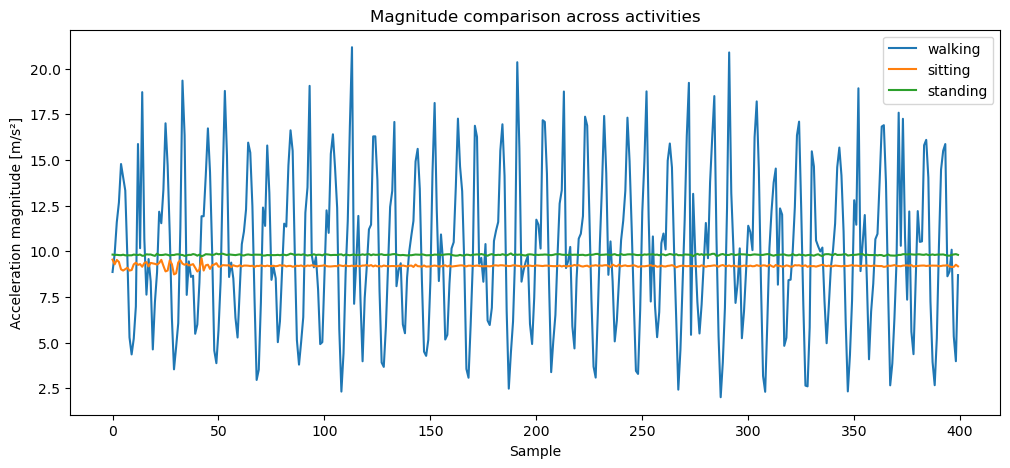

In [15]:
plt.figure(figsize=(12, 5))

for activity in TARGET_ACTIVITIES:
    signal = (
        df[df["activity"] == activity]["magnitude"]
        .head(400)
        .reset_index(drop=True)
    )
    plt.plot(signal, label=activity)

plt.title("Magnitude comparison across activities")
plt.xlabel("Sample")
plt.ylabel("Acceleration magnitude [m/s²]")
plt.legend()
plt.show()

## 6. Estimate sampling rate

The WISDM documentation states that the data was collected at approximately 20 Hz.  
We verify this using timestamp differences for one subject and one activity.

This is a useful engineering habit: do not only trust the documentation — check the data.

In [16]:
example_subject = int(df["subject_id"].iloc[0])
example_activity = "walking"

sample = df[
    (df["subject_id"] == example_subject) &
    (df["activity"] == example_activity)
].copy()

sample = sample.sort_values("timestamp")

timestamp_diffs = sample["timestamp"].diff().dropna()

mean_dt_ns = timestamp_diffs.mean()
estimated_sampling_rate = 1e9 / mean_dt_ns

print("Example subject:", example_subject)
print("Mean timestamp difference [ns]:", mean_dt_ns)
print("Estimated sampling rate [Hz]:", estimated_sampling_rate)

Example subject: 1600
Mean timestamp difference [ns]: 50354004.30198713
Estimated sampling rate [Hz]: 19.85939378331699


## 7. Windowing

Most classical machine learning models do not operate directly on raw time series streams.

Instead, we divide the signal into fixed-size windows.

For this project:

```text
sampling rate ≈ 20 Hz
window duration = 5 seconds
window size = 20 × 5 = 100 samples
```

Each window later becomes one machine learning example.

In [17]:
WINDOW_SIZE = 100  # 5 seconds at approximately 20 Hz

In [18]:
def create_windows(
    df: pd.DataFrame,
    window_size: int = WINDOW_SIZE,
) -> list[pd.DataFrame]:
    """
    Split a DataFrame into non-overlapping windows.

    Parameters
    ----------
    df:
        DataFrame containing samples from one subject and one activity.

    window_size:
        Number of samples per window.

    Returns
    -------
    list[pandas.DataFrame]
        List of windows, each containing window_size rows.
    """
    windows = []

    for start in range(0, len(df) - window_size + 1, window_size):
        end = start + window_size
        window = df.iloc[start:end].copy()
        windows.append(window)

    return windows

In [19]:
example_df = df[
    (df["subject_id"] == example_subject) &
    (df["activity"] == "walking")
].copy()

example_windows = create_windows(example_df, window_size=WINDOW_SIZE)

print("Number of example windows:", len(example_windows))
example_windows[0].head()

Number of example windows: 35


,subject_id,activity_code,timestamp,x,y,z,activity,magnitude
0,1600,A,252207666810782,-0.364761,8.793503,1.055084,walking,8.864082
1,1600,A,252207717164786,-0.879730,9.768784,1.016998,walking,9.860900
2,1600,A,252207767518790,2.001495,11.109070,2.619156,walking,11.587812
3,1600,A,252207817872794,0.450623,12.651642,0.184555,walking,12.661010
4,1600,A,252207868226798,-2.164352,13.928436,-4.422485,walking,14.773088


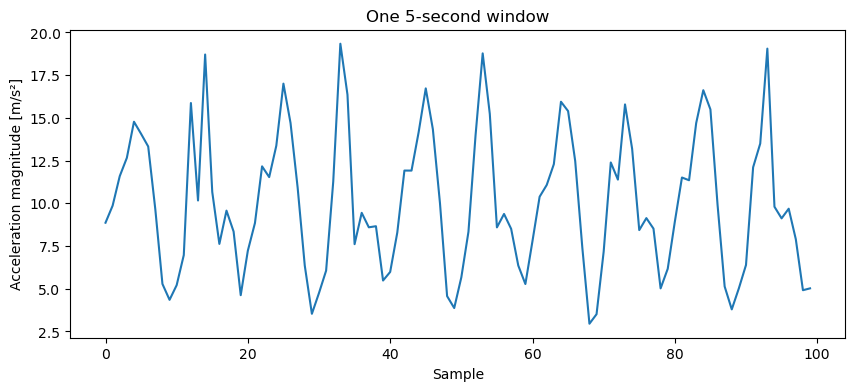

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(example_windows[0]["magnitude"])
plt.title("One 5-second window")
plt.xlabel("Sample")
plt.ylabel("Acceleration magnitude [m/s²]")
plt.show()

## 8. Feature extraction

A window still contains 100 raw samples.

To use a classical ML model, we convert each window into a feature vector.

For each of the signals `x`, `y`, `z`, and `magnitude`, we compute:

- mean
- standard deviation
- minimum
- maximum
- energy

This gives:

```text
4 signals × 5 features = 20 features
```

In [21]:
def extract_features(window: pd.DataFrame) -> dict[str, float]:
    """
    Extract statistical features from one sensor window.

    Parameters
    ----------
    window:
        DataFrame containing x, y, z and magnitude columns.

    Returns
    -------
    dict
        Feature dictionary with 20 numerical features.
    """
    features = {}

    for axis in ["x", "y", "z", "magnitude"]:
        signal = window[axis]

        features[f"mean_{axis}"] = float(signal.mean())
        features[f"std_{axis}"] = float(signal.std())
        features[f"min_{axis}"] = float(signal.min())
        features[f"max_{axis}"] = float(signal.max())
        features[f"energy_{axis}"] = float(np.sum(signal ** 2))

    return features

In [22]:
example_features = extract_features(example_windows[0])

pd.Series(example_features)

mean_x                 -1.000110
std_x                   1.892580
min_x                  -6.492264
max_x                   3.651398
energy_x              454.626037
mean_y                  9.619472
std_y                   3.986348
min_y                   2.684174
max_y                  18.676529
energy_y            10826.630357
mean_z                  0.340593
std_z                   2.082760
min_z                  -4.935730
max_z                   6.472199
energy_z              441.051585
mean_magnitude         10.036322
std_magnitude           4.081904
min_magnitude           2.954282
max_magnitude          19.337960
energy_magnitude    11722.307978
dtype: float64

In [23]:
print("Number of features:", len(example_features))

Number of features: 20


## 9. Build the feature dataset

We now apply windowing and feature extraction to all selected subjects and target activities.

Important:

- Windows are created separately for each subject and activity.
- This avoids windows that mix different activities.
- We keep the subject id for later subject-wise evaluation.

In [24]:
def build_feature_dataset(
    df: pd.DataFrame,
    window_size: int = WINDOW_SIZE,
) -> pd.DataFrame:
    """
    Convert raw sensor data into a feature dataset.

    Parameters
    ----------
    df:
        Raw sensor DataFrame containing subject_id, activity, x, y, z and magnitude.

    window_size:
        Number of samples per window.

    Returns
    -------
    pandas.DataFrame
        Feature dataset with one row per window.
    """
    rows = []

    grouped = df.groupby(["subject_id", "activity"], sort=True)

    for (subject_id, activity), group in grouped:
        group = group.sort_values("timestamp").copy()
        windows = create_windows(group, window_size=window_size)

        for window in windows:
            feature_row = extract_features(window)
            feature_row["subject_id"] = subject_id
            feature_row["activity"] = activity
            rows.append(feature_row)

    return pd.DataFrame(rows)

In [25]:
features_df = build_feature_dataset(df, window_size=WINDOW_SIZE)

features_df.head()

,mean_x,std_x,min_x,max_x,energy_x,mean_y,std_y,min_y,max_y,energy_y,...,min_z,max_z,energy_z,mean_magnitude,std_magnitude,min_magnitude,max_magnitude,energy_magnitude,subject_id,activity
0,3.845516,0.351159,2.627441,4.488892,1491.007201,4.827262,0.436838,4.073685,5.965424,2349.137987,...,5.959335,7.402969,4640.551276,9.207905,0.147174,8.731387,9.622650,8480.696464,1600,sitting
1,4.069495,0.031640,3.964447,4.144730,1656.178255,4.641167,0.033818,4.552872,4.714188,2154.156314,...,6.724777,6.911865,4645.141345,9.195336,0.023712,9.138906,9.270484,8455.475914,1600,sitting
2,4.098965,0.035909,3.981873,4.173141,1680.278813,4.643016,0.034376,4.534317,4.727310,2155.876513,...,6.690735,6.880447,4619.970527,9.195681,0.026681,9.118430,9.268516,8456.125854,1600,sitting
3,4.150756,0.041034,4.053879,4.252579,1723.044535,4.669522,0.044667,4.566193,4.779709,2180.641454,...,6.620407,6.872528,4558.969006,9.199233,0.025996,9.137887,9.260945,8462.654995,1600,sitting
4,4.135481,0.049281,3.972107,4.287186,1710.460832,4.656202,0.051068,4.526337,4.816910,2168.279808,...,6.640717,6.892288,4575.211893,9.194487,0.030782,9.120189,9.279861,8453.952534,1600,sitting


In [26]:
print("Feature dataset shape:", features_df.shape)

features_df["activity"].value_counts()

Feature dataset shape: (8066, 22)


activity
walking     2773
standing    2672
sitting     2621
Name: count, dtype: int64

In [27]:
missing_values = features_df.isna().sum().sum()
print("Missing values:", missing_values)

Missing values: 0


In [28]:
FEATURES_PATH = DATA_DIR / "features_df.csv"

features_df.to_csv(FEATURES_PATH, index=False)

print("Saved feature dataset to:", FEATURES_PATH)

Saved feature dataset to: /Users/konak/HPI/Vorlesungen/Data Engineering for Wearables SS2026/Mini-Project/de4w-live-activity-app/data/features_df.csv


## 10. Prepare features and labels

The target variable is `activity`.

The `subject_id` is not used as a model feature.  
We keep it only for subject-wise splitting and evaluation.

In [29]:
feature_columns = [
    col
    for col in features_df.columns
    if col not in ["activity", "subject_id"]
]

X = features_df[feature_columns]
y = features_df["activity"]

print("Number of feature columns:", len(feature_columns))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of feature columns: 20
X shape: (8066, 20)
y shape: (8066,)


## 11. Baseline evaluation: random train/test split

First, we use a standard random train/test split.

This is a common first experiment, but it can be overly optimistic for wearable data because the same subjects can appear in both train and test sets.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

rf_random = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
)

rf_random.fit(X_train, y_train)

y_pred = rf_random.predict(X_test)

random_split_accuracy = accuracy_score(y_test, y_pred)

print("Random split accuracy:", random_split_accuracy)
print()
print(classification_report(y_test, y_pred))

Random split accuracy: 0.9857496902106567

              precision    recall  f1-score   support

     sitting       0.99      0.98      0.98       524
    standing       0.98      0.99      0.98       535
     walking       0.98      1.00      0.99       555

    accuracy                           0.99      1614
   macro avg       0.99      0.99      0.99      1614
weighted avg       0.99      0.99      0.99      1614



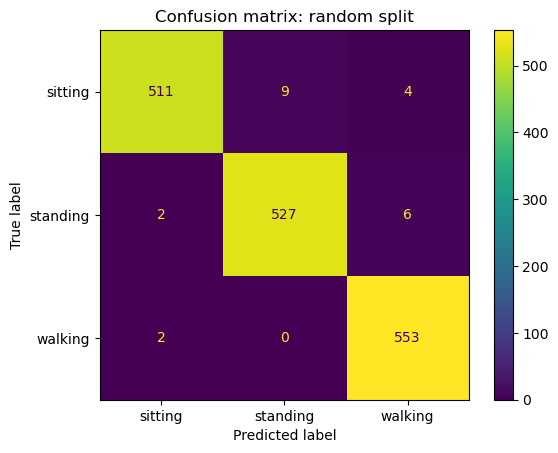

In [31]:
ConfusionMatrixDisplay.from_estimator(
    rf_random,
    X_test,
    y_test,
)
plt.title("Confusion matrix: random split")
plt.show()

## 12. Subject-wise evaluation

For wearable activity recognition, subject-wise evaluation is often more realistic.

Here, we split by subject:

- subjects in the training set are used for training
- subjects in the test set are completely unseen during training

This evaluates whether the model generalizes to new people.

In [32]:
subjects = features_df["subject_id"].unique()

train_subjects, test_subjects = train_test_split(
    subjects,
    test_size=0.2,
    random_state=42,
)

train_df = features_df[features_df["subject_id"].isin(train_subjects)].copy()
test_df = features_df[features_df["subject_id"].isin(test_subjects)].copy()

X_train_subject = train_df[feature_columns]
y_train_subject = train_df["activity"]

X_test_subject = test_df[feature_columns]
y_test_subject = test_df["activity"]

print("Number of train subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))
print("Train shape:", X_train_subject.shape)
print("Test shape:", X_test_subject.shape)

Number of train subjects: 40
Number of test subjects: 11
Train shape: (6522, 20)
Test shape: (1544, 20)


In [33]:
rf_subject = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
)

rf_subject.fit(X_train_subject, y_train_subject)

y_pred_subject = rf_subject.predict(X_test_subject)

subject_split_accuracy = accuracy_score(y_test_subject, y_pred_subject)

print("Subject-wise split accuracy:", subject_split_accuracy)
print()
print(classification_report(y_test_subject, y_pred_subject))

Subject-wise split accuracy: 0.8678756476683938

              precision    recall  f1-score   support

     sitting       0.75      0.91      0.82       516
    standing       0.90      0.70      0.78       514
     walking       0.98      1.00      0.99       514

    accuracy                           0.87      1544
   macro avg       0.88      0.87      0.87      1544
weighted avg       0.88      0.87      0.87      1544



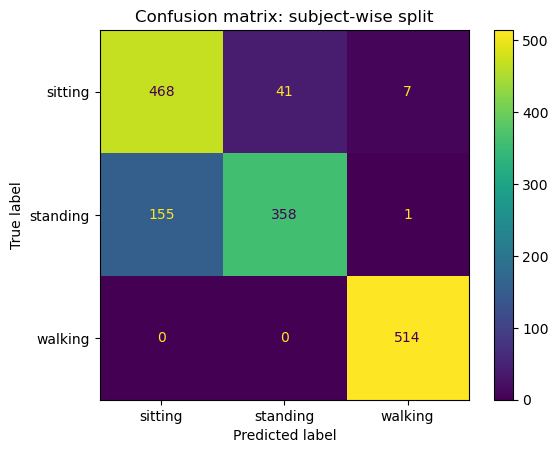

In [34]:
ConfusionMatrixDisplay.from_estimator(
    rf_subject,
    X_test_subject,
    y_test_subject,
)
plt.title("Confusion matrix: subject-wise split")
plt.show()

In [35]:
print("Random split accuracy:", random_split_accuracy)
print("Subject-wise split accuracy:", subject_split_accuracy)

Random split accuracy: 0.9857496902106567
Subject-wise split accuracy: 0.8678756476683938


## 13. Feature importance

Random Forest models allow us to inspect feature importance.

This is not a full explanation of the model, but it gives a first impression of which features are useful.

In [36]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_subject.feature_importances_,
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
16,std_magnitude,0.127982
14,energy_z,0.105725
11,std_z,0.103262
9,energy_y,0.089408
18,max_magnitude,0.079367
1,std_x,0.058988
6,std_y,0.058760
12,min_z,0.050793
10,mean_z,0.048638
17,min_magnitude,0.044854


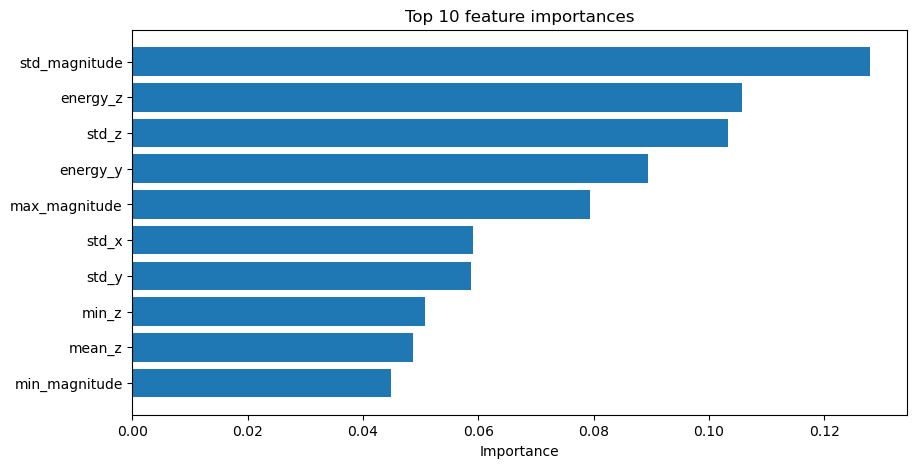

In [37]:
plt.figure(figsize=(10, 5))
plt.barh(
    importance_df.head(10)["feature"][::-1],
    importance_df.head(10)["importance"][::-1],
)
plt.title("Top 10 feature importances")
plt.xlabel("Importance")
plt.show()

## 14. Export model artifacts

For deployment, we need to save:

1. the trained model
2. the feature column order
3. the activity labels

The feature column order is essential.  
During live prediction, the incoming features must be passed to the model in exactly the same order as during training.

In [38]:
MODEL_PATH = MODEL_DIR / "activity_model_random_forest.joblib"
FEATURE_COLUMNS_PATH = MODEL_DIR / "feature_columns.joblib"
ACTIVITY_LABELS_PATH = MODEL_DIR / "activity_labels.joblib"

activity_labels = sorted(features_df["activity"].unique())

joblib.dump(rf_subject, MODEL_PATH)
joblib.dump(feature_columns, FEATURE_COLUMNS_PATH)
joblib.dump(activity_labels, ACTIVITY_LABELS_PATH)

print("Saved model to:", MODEL_PATH)
print("Saved feature columns to:", FEATURE_COLUMNS_PATH)
print("Saved activity labels to:", ACTIVITY_LABELS_PATH)

Saved model to: /Users/konak/HPI/Vorlesungen/Data Engineering for Wearables SS2026/Mini-Project/de4w-live-activity-app/models/activity_model_random_forest.joblib
Saved feature columns to: /Users/konak/HPI/Vorlesungen/Data Engineering for Wearables SS2026/Mini-Project/de4w-live-activity-app/models/feature_columns.joblib
Saved activity labels to: /Users/konak/HPI/Vorlesungen/Data Engineering for Wearables SS2026/Mini-Project/de4w-live-activity-app/models/activity_labels.joblib


## 15. Test exported model

Finally, we load the model again and test whether it can make predictions.

This simulates what will happen later in the application code.

In [39]:
loaded_model = joblib.load(MODEL_PATH)
loaded_feature_columns = joblib.load(FEATURE_COLUMNS_PATH)
loaded_activity_labels = joblib.load(ACTIVITY_LABELS_PATH)

print("Loaded labels:", loaded_activity_labels)

Loaded labels: ['sitting', 'standing', 'walking']


In [40]:
sample_row = X_test_subject.iloc[[0]]

prediction = loaded_model.predict(sample_row[loaded_feature_columns])[0]
probabilities = loaded_model.predict_proba(sample_row[loaded_feature_columns])[0]

print("True label:", y_test_subject.iloc[0])
print("Predicted label:", prediction)

pd.DataFrame(
    [probabilities],
    columns=loaded_model.classes_,
)

True label: sitting
Predicted label: walking


,sitting,standing,walking
0,0.125,0.08,0.795


## 16. Window-to-prediction test

This final test mirrors the later live application:

```text
raw sensor window
→ extract features
→ loaded model
→ prediction
```

In [44]:
test_window = example_windows[3]

test_features = extract_features(test_window)
test_features_df = pd.DataFrame([test_features])
test_features_df = test_features_df[loaded_feature_columns]

test_prediction = loaded_model.predict(test_features_df)[0]
test_probabilities = loaded_model.predict_proba(test_features_df)[0]

print("Prediction:", test_prediction)

pd.DataFrame(
    [test_probabilities],
    columns=loaded_model.classes_,
)

Prediction: walking


,sitting,standing,walking
0,0.0,0.0,1.0


## Summary

In this notebook, we created the offline machine learning part of the project:

```text
raw WISDM phone accelerometer data
→ windowing
→ feature extraction
→ Random Forest
→ subject-wise evaluation
→ exported model artifacts
```

The exported files in `models/` are used by the application code:

```text
models/activity_model_random_forest.joblib
models/feature_columns.joblib
models/activity_labels.joblib
```

Next step:

```text
Use the exported model in a Python application
→ FastAPI
→ Streamlit
→ phyphox live data
```